# Simple coordination

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# ========== パラメータ設定 ==========
N = 31  # グリッドサイズ NxN
MAX_STEPS = 100
p0 = 0.51# 初期norm1の割合
coordination_benefit = 1.0
alpha = 1.0  # シグモイド関数の鋭さ

# matplotlibカラー
from matplotlib.colors import ListedColormap
cmap_2strategy = ListedColormap(["blue", "red"])

# ========== 初期化 ==========
def initialize_grid(n, p0):
    return np.random.choice([0, 1], size=(n, n), p=[p0, 1-p0])

# ========== 利得計算 ==========
def calculate_payoffs(grid, benefit):
    """
    全エージェントに期待利得を一括割り当て。
    NetLogoと同様、全norm1の割合p1に依存。
    """
    p1 = np.mean(grid)
    norm1_payoff = 1 + p1 * benefit
    norm2_payoff = 1 + (1 - p1) * benefit
    payoff_grid = np.where(grid == 1, norm1_payoff, norm2_payoff)
    return payoff_grid

# ========== シグモイド模倣 ==========
def evolve(grid, payoff_grid, alpha=1.0):
    n = grid.shape[0]
    new_grid = grid.copy()
    for x in range(n):
        for y in range(n):
            # ランダムな別のエージェントを選んで観察
            rx, ry = np.random.randint(0, n), np.random.randint(0, n)
            payoff_self = payoff_grid[x, y]
            payoff_other = payoff_grid[rx, ry]
            prob_copy = 1 / (1 + np.exp(-alpha * (payoff_other - payoff_self)))
            if np.random.rand() < prob_copy:
                new_grid[x, y] = grid[rx, ry]
    return new_grid

# ========== シミュレーション全体 ==========
def run_simulation(steps=MAX_STEPS):
    grid = initialize_grid(N, p0)
    history = [grid.copy()]
    for _ in range(steps):
        payoff_grid = calculate_payoffs(grid, coordination_benefit)
        grid = evolve(grid, payoff_grid, alpha)
        history.append(grid.copy())
    return history

# ========== アニメーション生成 ==========
def animate(history):
    fig, ax = plt.subplots(figsize=(5, 5))
    im = ax.imshow(history[0], cmap=cmap_2strategy, vmin=0, vmax=1)
    ax.set_title("Blue = norm1?, Red = norm2?")
    ax.set_xticks([]); ax.set_yticks([])

    def update(frame):
        im.set_data(history[frame])
        return [im]

    ani = FuncAnimation(fig, update, frames=len(history), interval=200, blit=True)
    return HTML(ani.to_jshtml())

# ========== 実行 ==========
history = run_simulation()
#animate(history)


## $\delta$ = 0でののゆらぎ

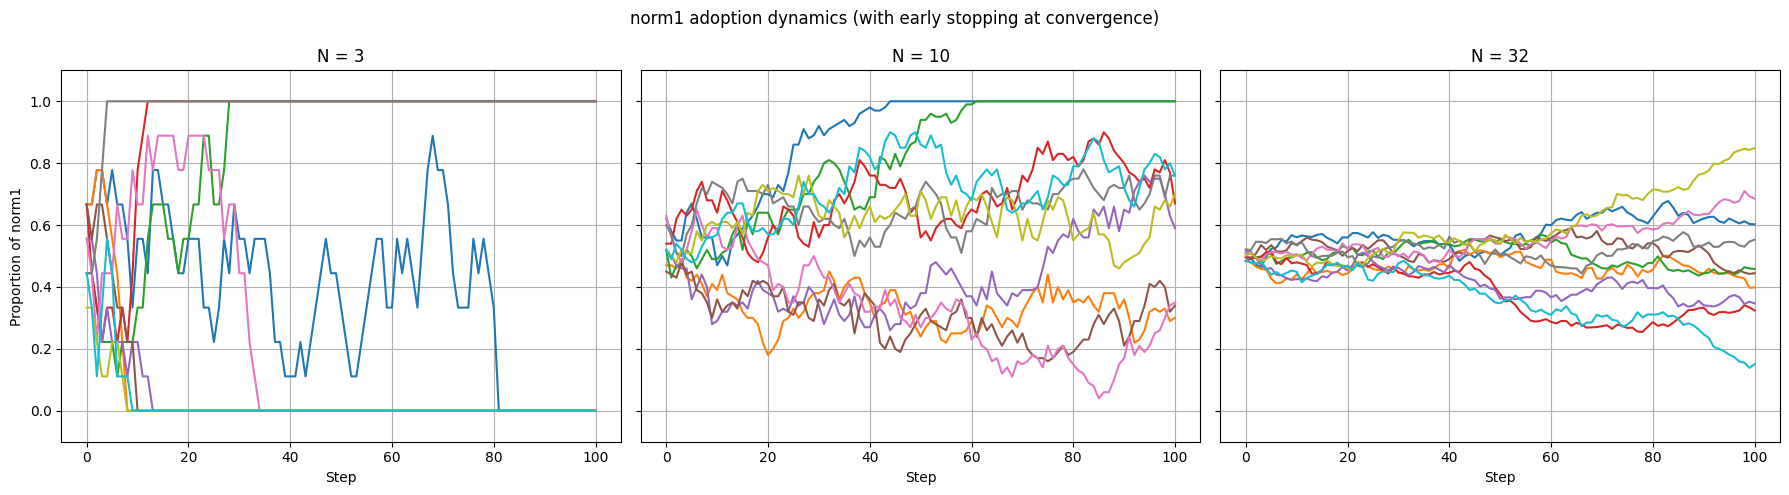

In [48]:
import numpy as np
import matplotlib.pyplot as plt

# ========== パラメータ設定 ==========
MAX_STEPS = 100
coordination_benefit = 0
alpha = 1
p0 = 0.5
NUM_RUNS = 10
Ns = [3, 10, 32]

# ========== 初期化 ==========
def initialize_grid(n, p0):
    return np.random.choice([0, 1], size=(n, n), p=[1-p0, p0])

# ========== 利得計算 ==========
def calculate_payoffs(grid, benefit):
    p1 = np.mean(grid)
    norm1_payoff = 1 + p1 * benefit
    norm2_payoff = 1 + (1 - p1) * benefit
    return np.where(grid == 1, norm1_payoff, norm2_payoff)

# ========== 進化ルール ==========
def evolve(grid, payoff_grid, alpha=1.0):
    n = grid.shape[0]
    rx = np.random.randint(0, n, size=(n, n))
    ry = np.random.randint(0, n, size=(n, n))
    new_grid = grid.copy()
    for x in range(n):
        for y in range(n):
            model_x, model_y = rx[x, y], ry[x, y]
            payoff_self = payoff_grid[x, y]
            payoff_other = payoff_grid[model_x, model_y]
            prob_copy = 1 / (1 + np.exp(-alpha * (payoff_other - payoff_self)))
            if np.random.rand() < prob_copy:
                new_grid[x, y] = grid[model_x, model_y]
    return new_grid

# ========== シミュレーション ==========
def run_simulation(N, steps=MAX_STEPS):
    grid = initialize_grid(N, p0)
    p1_history = [np.mean(grid)]
    for _ in range(steps):
        if p1_history[-1] == 0 or p1_history[-1] == 1:
            p1_history.extend([p1_history[-1]] * (steps - len(p1_history)))
            break
        payoff_grid = calculate_payoffs(grid, coordination_benefit)
        grid = evolve(grid, payoff_grid, alpha)
        p1_history.append(np.mean(grid))
    while len(p1_history) <= steps:
        p1_history.append(p1_history[-1])
    return p1_history

# ========== プロット ==========
fig, axes = plt.subplots(1, len(Ns), figsize=(18, 5), sharey=True)

for idx, N in enumerate(Ns):
    ax = axes[idx]
    for run in range(NUM_RUNS):
        p1_series = run_simulation(N)
        ax.plot(p1_series, label=f'Run {run+1}')
    ax.set_title(f'N = {N}')
    ax.set_xlabel('Step')
    ax.set_ylim(-0.1, 1.1)
    if idx == 0:
        ax.set_ylabel('Proportion of norm1')
    ax.grid(True)

plt.suptitle('norm1 adoption dynamics (with early stopping at convergence)')
plt.tight_layout()
plt.show()


## 初期割合ごとの収束率の違い ($\delta$ = 1であることに注意)


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


100%|█████████████████████████████████████████████████████████████████████████████████████████████| 41/41 [01:06<00:00,  1.61s/it]


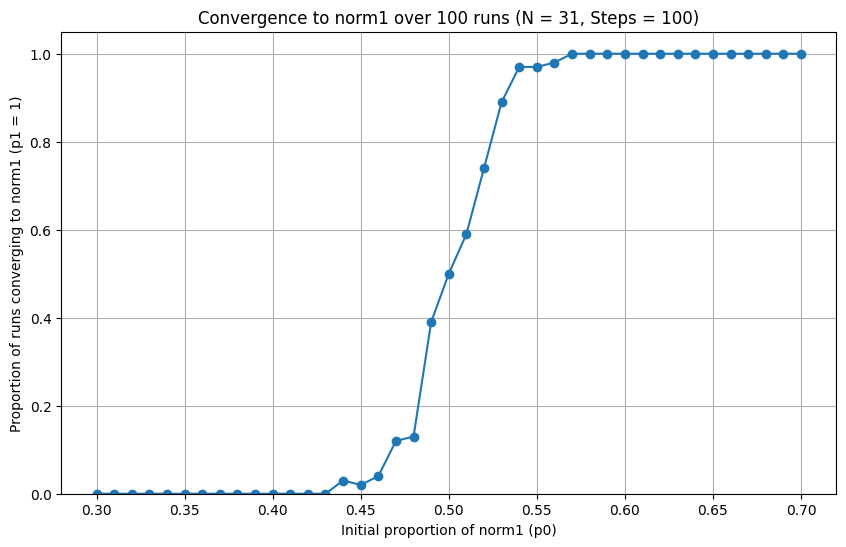

In [49]:
!pip install tqdm
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# ====== モデル設定 ======
MAX_STEPS = 100
coordination_benefit = 1
alpha = 1.0
N = 31
NUM_RUNS = 100

# ====== 初期化関数 ======
def initialize_grid(n, p0):
    return np.random.choice([0, 1], size=(n, n), p=[1 - p0, p0])

# ====== 利得関数 ======
def calculate_payoffs(grid, benefit):
    p1 = np.mean(grid)
    norm1_payoff = 1 + p1 * benefit
    norm2_payoff = 1 + (1 - p1) * benefit
    return np.where(grid == 1, norm1_payoff, norm2_payoff)

# ====== 進化関数 ======
def evolve(grid, payoff_grid, alpha=1.0):
    n = grid.shape[0]
    rx = np.random.randint(0, n, size=(n, n))
    ry = np.random.randint(0, n, size=(n, n))
    new_grid = grid.copy()
    for x in range(n):
        for y in range(n):
            model_x, model_y = rx[x, y], ry[x, y]
            payoff_self = payoff_grid[x, y]
            payoff_other = payoff_grid[model_x, model_y]
            prob_copy = 1 / (1 + np.exp(-alpha * (payoff_other - payoff_self)))
            if np.random.rand() < prob_copy:
                new_grid[x, y] = grid[model_x, model_y]
    return new_grid

# ====== 単回シミュレーション ======
def run_simulation(N, p0, steps=MAX_STEPS):
    grid = initialize_grid(N, p0)
    for _ in range(steps):
        if np.all(grid == 1):
            return 1  # norm1に収束
        elif np.all(grid == 0):
            return 0  # norm2に収束
        payoff_grid = calculate_payoffs(grid, coordination_benefit)
        grid = evolve(grid, payoff_grid, alpha)
    return int(np.all(grid == 1))  # 最終時点での状態確認

# ====== メイン処理 ======
p0_values = np.arange(0.3, 0.71, 0.01)
proportions = []

for p0 in tqdm(p0_values):
    successes = sum(run_simulation(N, p0) for _ in range(NUM_RUNS))
    proportions.append(successes / NUM_RUNS)

# ====== プロット ======
plt.figure(figsize=(10, 6))
plt.plot(p0_values, proportions, marker='o')
plt.xlabel('Initial proportion of norm1 (p0)')
plt.ylabel('Proportion of runs converging to norm1 (p1 = 1)')
plt.title(f'Convergence to norm1 over 100 runs (N = {N}, Steps = {MAX_STEPS})')
plt.grid(True)
plt.ylim(0, 1.05)
plt.show()


# 協力による利益g、協力失敗コストhを導入 ($g = 1, h = 0.5$)

100%|█████████████████████████████████████████████████████████████████████████████████████████████| 31/31 [01:15<00:00,  2.45s/it]


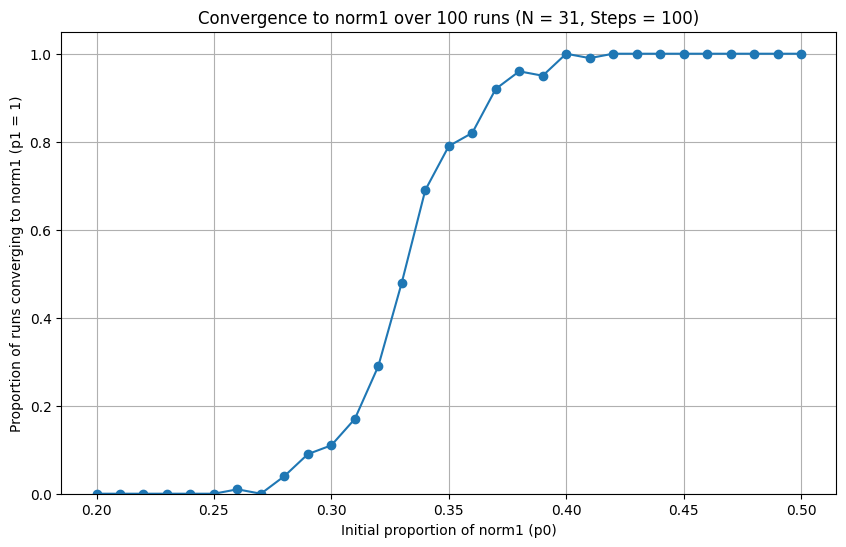

In [50]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# ====== モデル設定 ======
MAX_STEPS = 100
n1_prosocial_benefit = 1
n1_coord_benefit = 1
n1_rarity_cost = 0.5

alpha = 1.0
N = 31
NUM_RUNS = 100

# ====== 初期化関数 ======
def initialize_grid(n, p0):
    return np.random.choice([0, 1], size=(n, n), p=[1 - p0, p0])

# ====== 利得関数 ======
def calculate_payoffs(grid, benefit):
    p1 = np.mean(grid)
    norm1_payoff = p1 * (1 + n1_prosocial_benefit + n1_coord_benefit) +(1 - p1) * (1 - n1_rarity_cost)
    norm2_payoff = p1 * (1 + n1_prosocial_benefit) + (1 - p1) *1
    return np.where(grid == 1, norm1_payoff, norm2_payoff)

# ====== 進化関数 ======
def evolve(grid, payoff_grid, alpha=1.0):
    n = grid.shape[0]
    rx = np.random.randint(0, n, size=(n, n))
    ry = np.random.randint(0, n, size=(n, n))
    new_grid = grid.copy()
    for x in range(n):
        for y in range(n):
            model_x, model_y = rx[x, y], ry[x, y]
            payoff_self = payoff_grid[x, y]
            payoff_other = payoff_grid[model_x, model_y]
            prob_copy = 1 / (1 + np.exp(-alpha * (payoff_other - payoff_self)))
            if np.random.rand() < prob_copy:
                new_grid[x, y] = grid[model_x, model_y]
    return new_grid

# ====== 単回シミュレーション ======
def run_simulation(N, p0, steps=MAX_STEPS):
    grid = initialize_grid(N, p0)
    for _ in range(steps):
        if np.all(grid == 1):
            return 1  # norm1に収束
        elif np.all(grid == 0):
            return 0  # norm2に収束
        payoff_grid = calculate_payoffs(grid, coordination_benefit)
        grid = evolve(grid, payoff_grid, alpha)
    return int(np.all(grid == 1))  # 最終時点での状態確認

# ====== メイン処理 ======
p0_values = np.arange(0.2, 0.51, 0.01)
proportions = []

for p0 in tqdm(p0_values):
    successes = sum(run_simulation(N, p0) for _ in range(NUM_RUNS))
    proportions.append(successes / NUM_RUNS)

# ====== プロット ======
plt.figure(figsize=(10, 6))
plt.plot(p0_values, proportions, marker='o')
plt.xlabel('Initial proportion of norm1 (p0)')
plt.ylabel('Proportion of runs converging to norm1 (p1 = 1)')
plt.title(f'Convergence to norm1 over 100 runs (N = {N}, Steps = {MAX_STEPS})')
plt.grid(True)
plt.ylim(0, 1.05)
plt.show()


# 隣の芝生は青い

In [56]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.colors import ListedColormap
from IPython.display import HTML

# ====== モデル設定 ======
MAX_STEPS = 100
n1_prosocial_benefit = 1
n1_coord_benefit = 1
n1_rarity_cost = 0.5

alpha = 1.0
N = 31

# カラーマップ
cmap_2strategy = ListedColormap(["blue", "red"])

# ====== 初期化関数 ======
def initialize_grid(n, p0):
    return np.random.choice([0, 1], size=(n, n), p=[1 - p0, p0])

# ====== 利得関数 ======
def calculate_payoffs(grid):
    p1 = np.mean(grid)
    norm1_payoff = p1 * (1 + n1_prosocial_benefit + n1_coord_benefit) + (1 - p1) * (1 - n1_rarity_cost)
    norm2_payoff = p1 * (1 + n1_prosocial_benefit) + (1 - p1) * 1
    return np.where(grid == 1, norm1_payoff, norm2_payoff)

# ====== 進化関数（他グリッド参照あり） ======
def evolve_with_cross_reference(grid_a, grid_b, payoff_a, payoff_b, alpha=1.0):
    n = grid_a.shape[0]
    new_grid = grid_a.copy()
    rx = np.random.randint(0, n, size=(n, n))
    ry = np.random.randint(0, n, size=(n, n))

    for x in range(n):
        for y in range(n):
            if np.random.rand() < 0.15:
                model_grid = grid_b
                model_payoff = payoff_b
            else:
                model_grid = grid_a
                model_payoff = payoff_a

            mx, my = rx[x, y], ry[x, y]
            payoff_self = payoff_a[x, y]
            payoff_other = model_payoff[mx, my]
            prob_copy = 1 / (1 + np.exp(-alpha * (payoff_other - payoff_self)))
            if np.random.rand() < prob_copy:
                new_grid[x, y] = model_grid[mx, my]
    return new_grid

# ====== シミュレーション実行 ======
def run_dual_simulation(N=31, p0_a=0.3, p0_b=0.7, steps=100):
    grid_a = initialize_grid(N, p0_a)
    grid_b = initialize_grid(N, p0_b)

    history_a = [grid_a.copy()]
    history_b = [grid_b.copy()]

    for _ in range(steps):
        payoff_a = calculate_payoffs(grid_a)
        payoff_b = calculate_payoffs(grid_b)
        grid_a = evolve_with_cross_reference(grid_a, grid_b, payoff_a, payoff_b, alpha)
        grid_b = evolve_with_cross_reference(grid_b, grid_a, payoff_b, payoff_a, alpha)
        history_a.append(grid_a.copy())
        history_b.append(grid_b.copy())

    return history_a, history_b

# ====== アニメーション表示 ======
def animate_dual(history_a, history_b):
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    im_a = axes[0].imshow(history_a[0], cmap=cmap_2strategy, vmin=0, vmax=1)
    im_b = axes[1].imshow(history_b[0], cmap=cmap_2strategy, vmin=0, vmax=1)

    axes[0].set_title("Grid A")
    axes[1].set_title("Grid B")
    for ax in axes:
        ax.set_xticks([]); ax.set_yticks([])

    def update(frame):
        im_a.set_data(history_a[frame])
        im_b.set_data(history_b[frame])
        return [im_a, im_b]

    ani = FuncAnimation(fig, update, frames=len(history_a), interval=200, blit=True)
    return HTML(ani.to_jshtml())

# ====== 実行例 ======
#history_a, history_b = run_dual_simulation(p0_a=0.2, p0_b=0.7)
#animate_dual(history_a, history_b)


rarity_cost=1.0: 100%|██████████████████████████████████████████████████████████████████████████| 101/101 [35:47<00:00, 21.27s/it]


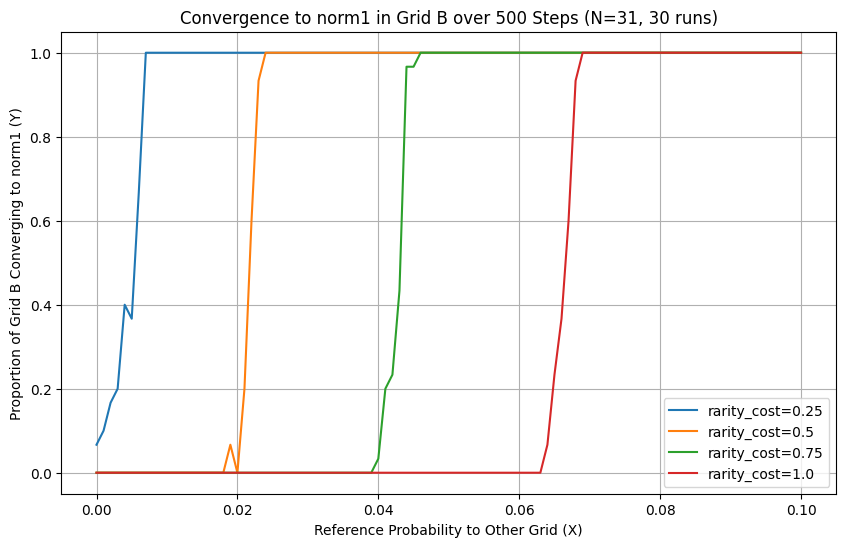

In [57]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# ====== モデルパラメータ（定数部分） ======
MAX_STEPS = 500
n1_prosocial_benefit = 1
n1_coord_benefit = 1
alpha = 1.0
N = 31
NUM_RUNS = 30  # 各条件でのシミュレーション回数

# ====== グリッド初期化 ======
def initialize_grid(n, p0):
    return np.random.choice([0, 1], size=(n, n), p=[1 - p0, p0])

# ====== 利得計算 ======
def calculate_payoffs(grid, rarity_cost):
    p1 = np.mean(grid)
    norm1_payoff = p1 * (1 + n1_prosocial_benefit + n1_coord_benefit) + (1 - p1) * (1 - rarity_cost)
    norm2_payoff = p1 * (1 + n1_prosocial_benefit) + (1 - p1) * 1
    return np.where(grid == 1, norm1_payoff, norm2_payoff)

# ====== 進化（クロス参照あり） ======
def evolve_with_cross_reference(grid_a, grid_b, payoff_a, payoff_b, alpha, other_ref_prob):
    n = grid_a.shape[0]
    new_grid = grid_a.copy()
    rx = np.random.randint(0, n, size=(n, n))
    ry = np.random.randint(0, n, size=(n, n))

    for x in range(n):
        for y in range(n):
            if np.random.rand() < other_ref_prob:
                model_grid = grid_b
                model_payoff = payoff_b
            else:
                model_grid = grid_a
                model_payoff = payoff_a

            mx, my = rx[x, y], ry[x, y]
            payoff_self = payoff_a[x, y]
            payoff_other = model_payoff[mx, my]
            prob_copy = 1 / (1 + np.exp(-alpha * (payoff_other - payoff_self)))
            if np.random.rand() < prob_copy:
                new_grid[x, y] = model_grid[mx, my]
    return new_grid

# ====== シミュレーション本体 ======
def run_simulation(other_ref_prob, rarity_cost, steps=MAX_STEPS):
    grid_a = initialize_grid(N, 0.8)  # 修正：位置引数で指定
    grid_b = initialize_grid(N, 0.15)

    for _ in range(steps):
        payoff_a = calculate_payoffs(grid_a, rarity_cost)
        payoff_b = calculate_payoffs(grid_b, rarity_cost)
        grid_a = evolve_with_cross_reference(grid_a, grid_b, payoff_a, payoff_b, alpha, other_ref_prob)
        grid_b = evolve_with_cross_reference(grid_b, grid_a, payoff_b, payoff_a, alpha, other_ref_prob)
        
        if np.all(grid_b == 1):
            return 1
        elif np.all(grid_b == 0):
            return 0

    return int(np.all(grid_b == 1))

# ====== 探索と可視化 ======
ref_probs = np.arange(0.0, 0.101, 0.001)
rarity_costs = [0.25, 0.5, 0.75, 1.0]
results = {}

for rarity_cost in rarity_costs:
    ys = []
    for ref_prob in tqdm(ref_probs, desc=f"rarity_cost={rarity_cost}"):
        success_count = sum(run_simulation(ref_prob, rarity_cost) for _ in range(NUM_RUNS))
        ys.append(success_count / NUM_RUNS)
    results[rarity_cost] = ys

# ====== プロット ======
plt.figure(figsize=(10, 6))
for rarity_cost in rarity_costs:
    plt.plot(ref_probs, results[rarity_cost], label=f"rarity_cost={rarity_cost}")
plt.xlabel("Reference Probability to Other Grid (X)")
plt.ylabel("Proportion of Grid B Converging to norm1 (Y)")
plt.title(f"Convergence to norm1 in Grid B over 500 Steps (N={N}, {NUM_RUNS} runs)")
plt.grid(True)
plt.legend()
plt.ylim(-0.05, 1.05)
plt.show()


ref_prob=0.018: 100%|█████████████████████████████████████████████████████████████████████████████| 31/31 [10:11<00:00, 19.72s/it]


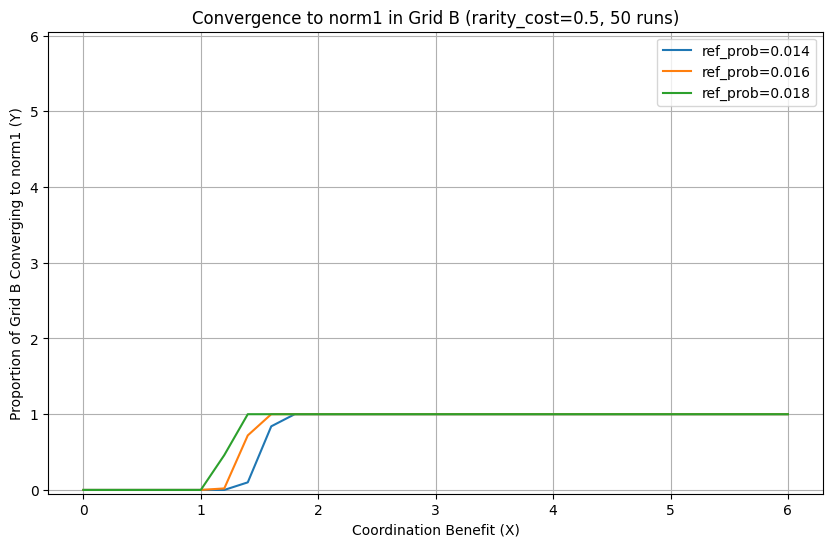

In [58]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# ====== モデルパラメータ（定数部分） ======
MAX_STEPS = 1000
n1_prosocial_benefit = 1
alpha = 1.0
N = 31
NUM_RUNS = 50  # 各条件でのシミュレーション回数
rarity_cost = 0.5  # 固定

# ====== グリッド初期化 ======
def initialize_grid(n, p0):
    return np.random.choice([0, 1], size=(n, n), p=[1 - p0, p0])

# ====== 利得計算 ======
def calculate_payoffs(grid, coord_benefit):
    p1 = np.mean(grid)
    norm1_payoff = p1 * (1 + n1_prosocial_benefit + coord_benefit) + (1 - p1) * (1 - rarity_cost)
    norm2_payoff = p1 * (1 + n1_prosocial_benefit) + (1 - p1) * 1
    return np.where(grid == 1, norm1_payoff, norm2_payoff)

# ====== 進化（クロス参照あり） ======
def evolve_with_cross_reference(grid_a, grid_b, payoff_a, payoff_b, alpha, other_ref_prob):
    n = grid_a.shape[0]
    new_grid = grid_a.copy()
    rx = np.random.randint(0, n, size=(n, n))
    ry = np.random.randint(0, n, size=(n, n))

    for x in range(n):
        for y in range(n):
            if np.random.rand() < other_ref_prob:
                model_grid = grid_b
                model_payoff = payoff_b
            else:
                model_grid = grid_a
                model_payoff = payoff_a

            mx, my = rx[x, y], ry[x, y]
            payoff_self = payoff_a[x, y]
            payoff_other = model_payoff[mx, my]
            prob_copy = 1 / (1 + np.exp(-alpha * (payoff_other - payoff_self)))
            if np.random.rand() < prob_copy:
                new_grid[x, y] = model_grid[mx, my]
    return new_grid

# ====== シミュレーション本体 ======
def run_simulation(other_ref_prob, coord_benefit, steps=MAX_STEPS):
    grid_a = initialize_grid(N, 0.8)
    grid_b = initialize_grid(N, 0.15)

    for _ in range(steps):
        payoff_a = calculate_payoffs(grid_a, coord_benefit)
        payoff_b = calculate_payoffs(grid_b, coord_benefit)
        grid_a = evolve_with_cross_reference(grid_a, grid_b, payoff_a, payoff_b, alpha, other_ref_prob)
        grid_b = evolve_with_cross_reference(grid_b, grid_a, payoff_b, payoff_a, alpha, other_ref_prob)

        if np.all(grid_b == 1):
            return 1
        elif np.all(grid_b == 0):
            return 0

    return int(np.all(grid_b == 1))

# ====== 探索と可視化 ======
coord_benefits = np.arange(0.0, 6.01, 0.2)
ref_probs = [0.014, 0.016, 0.018]
results = {}

for ref_prob in ref_probs:
    ys = []
    for coord_benefit in tqdm(coord_benefits, desc=f"ref_prob={ref_prob}"):
        success_count = sum(run_simulation(ref_prob, coord_benefit) for _ in range(NUM_RUNS))
        ys.append(success_count / NUM_RUNS)
    results[ref_prob] = ys

# ====== プロット ======
plt.figure(figsize=(10, 6))
for ref_prob in ref_probs:
    plt.plot(coord_benefits, results[ref_prob], label=f"ref_prob={ref_prob}")
plt.xlabel("Coordination Benefit (X)")
plt.ylabel("Proportion of Grid B Converging to norm1 (Y)")
plt.title(f"Convergence to norm1 in Grid B (rarity_cost={rarity_cost}, {NUM_RUNS} runs)")
plt.grid(True)
plt.legend()
plt.ylim(-0.05, 6.05)
plt.show()
